# E-commerce User Behavior Analysis

## Objective
The purpose of this project is to analyze user behavior in an e-commerce dataset and identify patterns in conversion, category performance, and purchase behavior.

## Business Question
How can we improve conversion rates and better understand user behavior across the funnel (view → cart → purchase)?

In [1]:
# ==========================================
# 1. Import libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ==========================================
# 2. Function: robust random sample from a large CSV
# Reads file in chunks and samples across the whole file
# ==========================================
def sample_csv_in_chunks(path, sample_size=50000, chunk_size=200000, random_state=42):
    rng = np.random.default_rng(random_state)
    samples = []
    total_seen = 0

    for chunk in pd.read_csv(path, chunksize=chunk_size):
        n = len(chunk)
        total_seen += n

        # how many rows to keep from this chunk, proportional to chunk size
        frac = sample_size / total_seen
        k = min(n, max(1, int(round(n * frac))))

        chunk_sample = chunk.sample(n=k, random_state=int(rng.integers(0, 1_000_000)))
        samples.append(chunk_sample)

    sampled = pd.concat(samples, ignore_index=True)

    # final exact sample size
    if len(sampled) > sample_size:
        sampled = sampled.sample(n=sample_size, random_state=random_state)

    return sampled.reset_index(drop=True)

# ==========================================
# 3. Take equal random samples from each month
# ==========================================
sample_size_per_month = 50000

df_oct = sample_csv_in_chunks(
    "Data/2019-Oct.csv",
    sample_size=sample_size_per_month,
    chunk_size=200000,
    random_state=42
)

df_nov = sample_csv_in_chunks(
    "Data/2019-Nov.csv",
    sample_size=sample_size_per_month,
    chunk_size=200000,
    random_state=43
)

# ==========================================
# 4. Combine balanced samples
# ==========================================
df = pd.concat([df_oct, df_nov], ignore_index=True)

# ==========================================
# 5. Basic preprocessing
# ==========================================
df["event_time"] = pd.to_datetime(df["event_time"])

# ==========================================
# 6. Quick sanity check
# ==========================================
print(df["event_time"].dt.to_period("M").value_counts())

# ==========================================
# 7. Preview
# ==========================================
df.head()

2019-10    50000
2019-11    50000
Freq: M, Name: event_time, dtype: int64


C:\Users\vafli\AppData\Local\Temp\ipykernel_32760\3158302055.py:70: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(df["event_time"].dt.to_period("M").value_counts())


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-25 17:17:31+00:00,view,15100133,2053013557024391671,NaN,NaN,312.98,514514154,d4398ee0-b168-4555-abfe-c64a537f328e
1,2019-10-01 04:10:31+00:00,view,6201019,2053013552293216471,appliances.environment.air_heater,NaN,36.53,513343470,d998c4a6-31c3-445f-ae5c-852fb3f9805f
2,2019-10-08 17:16:17+00:00,view,2601543,2053013563970159485,NaN,hansa,411.59,554703232,8aad2faf-9dd8-48a4-abd1-20bdd6f70abf
3,2019-10-01 08:24:18+00:00,view,1004767,2053013555631882655,electronics.smartphone,samsung,254.26,512421983,c3b1481c-d51f-45f6-bc06-5574cba91179
4,2019-10-19 16:53:40+00:00,view,2600397,2053013563970159485,NaN,NaN,156.99,512895628,d384e751-ad9b-4bdc-a77b-c261e10a8ac5


## Data Overview

In this section, we explore the structure of the dataset, including columns, data types, and missing values.
This helps us understand the data before performing any analysis.

In [2]:
# Check dataset size (rows, columns)
df.shape

(100000, 9)

In [3]:
# Get overview of columns, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     100000 non-null  datetime64[ns, UTC]
 1   event_type     100000 non-null  object             
 2   product_id     100000 non-null  int64              
 3   category_id    100000 non-null  int64              
 4   category_code  67826 non-null   object             
 5   brand          85530 non-null   object             
 6   price          100000 non-null  float64            
 7   user_id        100000 non-null  int64              
 8   user_session   100000 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 6.9+ MB


In [4]:
# Summary statistics for numerical columns
df.describe()

,product_id,category_id,price,user_id
count,1.000000e+05,1.000000e+05,100000.000000,1.000000e+05
mean,1.076414e+07,2.057326e+18,291.047962,5.341372e+08
std,1.257169e+07,1.840876e+16,356.195084,1.938858e+07
min,1.000978e+06,2.053014e+18,0.000000,2.575855e+08
25%,1.005177e+06,2.053014e+18,66.112500,5.158990e+08
50%,5.100337e+06,2.053014e+18,164.110000,5.298719e+08
75%,1.620030e+07,2.053014e+18,360.340000,5.519867e+08
max,1.000241e+08,2.181923e+18,2574.070000,5.799043e+08


In [5]:
# Check missing values in each column
df.isnull().sum()

event_time           0
event_type           0
product_id           0
category_id          0
category_code    32174
brand            14470
price                0
user_id              0
user_session         0
dtype: int64

### Observations

The dataset contains event-level data where each row represents a user interaction.

Key columns include:
- event_type (view, cart, purchase)
- product_id and category information
- price
- user_id and user_session

Some columns, such as `category_code` and `brand`, contain missing values.
This is important to consider in later analysis.

## Data Cleaning

Before analysis, we perform basic data cleaning to ensure correct data types and remove unnecessary missing values where needed.

In [6]:
# Create a cleaned copy of the dataset
df_clean = df.copy()

In [7]:
# Remove rows where category_code is missing (needed for category analysis)
df_clean = df_clean.dropna(subset=["category_code"])

In [8]:
# Check new shape after cleaning
df_clean.shape

(67826, 9)

### Cleaning Summary

- Created a cleaned dataset (`df_clean`) for category-based analysis
- Removed rows with missing `category_code` where category information was required

This ensures more reliable results in the category and pricing sections.

## Funnel Analysis

In this section, we analyze how users move through the e-commerce funnel:

View → Cart → Purchase

This helps identify where users drop off and where improvements can be made to increase conversion.

In [9]:
# Count number of events by type
event_counts = df["event_type"].value_counts()

event_counts

view        96191
cart         2116
purchase     1693
Name: event_type, dtype: int64

In [10]:
# Extract counts
views = event_counts.get("view", 0)
carts = event_counts.get("cart", 0)
purchases = event_counts.get("purchase", 0)

print("Views:", views)
print("Carts:", carts)
print("Purchases:", purchases)

Views: 96191
Carts: 2116
Purchases: 1693


In [11]:
# Calculate conversion rates
cart_rate = carts / views if views > 0 else 0
purchase_rate = purchases / views if views > 0 else 0
purchase_from_cart_rate = purchases / carts if carts > 0 else 0

print("Cart rate (view → cart):", cart_rate)
print("Purchase rate (view → purchase):", purchase_rate)
print("Purchase rate (cart → purchase):", purchase_from_cart_rate)

Cart rate (view → cart): 0.021997900011435582
Purchase rate (view → purchase): 0.017600399205746898
Purchase rate (cart → purchase): 0.8000945179584121


The dataset is event-based, meaning that multiple events can be recorded per user.

Therefore, these metrics should be interpreted as event-level indicators rather than strict user-level conversion rates.

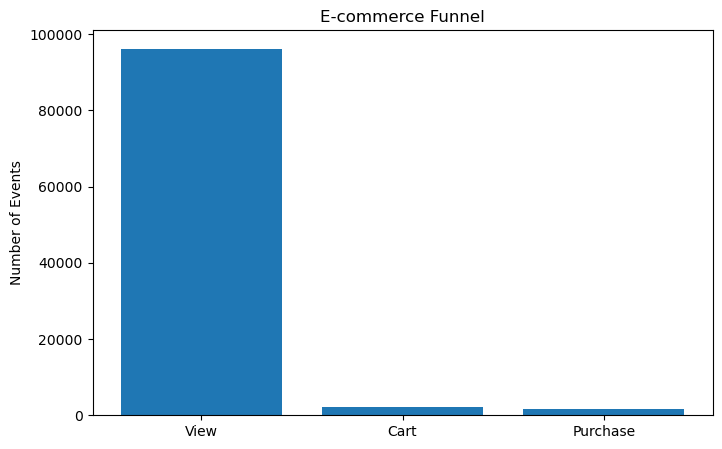

In [12]:
# Funnel visualization
funnel_labels = ["View", "Cart", "Purchase"]
funnel_values = [views, carts, purchases]

plt.figure(figsize=(8,5))
plt.bar(funnel_labels, funnel_values)
plt.title("E-commerce Funnel")
plt.ylabel("Number of Events")
plt.show()

### Insight

The funnel analysis shows a clear drop-off between product views and completed purchases.

A large number of users view products, but only a smaller proportion proceed to add items to cart and complete a purchase.

This suggests potential friction in the user journey, such as:
- lack of purchase intent
- pricing concerns
- or issues in the cart/checkout process

Improving conversion at these stages could significantly impact overall sales.

## Category Analysis

In this section, we analyze how different product categories perform in terms of user engagement and conversion.

The goal is to identify:
- categories with high user interest (many views)
- categories with strong purchase performance
- categories with low conversion despite high traffic


In [13]:
# Count events by category and event type
category_events = df_clean.groupby(["category_code", "event_type"]).size().unstack(fill_value=0)

category_events.head()

event_type,cart,purchase,view
category_code,,,
accessories.bag,0,4,399
accessories.umbrella,0,0,6
accessories.wallet,0,1,97
apparel.belt,0,0,3
apparel.costume,0,1,269


In [14]:
category_filtered = category_events[category_events["view"] >= 100].copy()
category_filtered["conversion_rate"] = category_filtered["purchase"] / category_filtered["view"]

category_conversion = category_filtered.sort_values(by="conversion_rate", ascending=False)
category_conversion.head(10)

event_type,cart,purchase,view,conversion_rate
category_code,,,,
electronics.smartphone,1249,773,24346,0.031751
electronics.audio.headphone,134,74,2360,0.031356
computers.components.hdd,2,4,146,0.027397
electronics.tablet,15,19,728,0.026099
appliances.environment.water_heater,5,8,342,0.023392
appliances.kitchen.washer,43,43,1886,0.022800
appliances.iron,3,8,377,0.021220
electronics.video.tv,65,53,2629,0.020160
appliances.environment.air_conditioner,0,2,100,0.020000


In [15]:
# Top categories by views
top_viewed = category_events.sort_values(by="view", ascending=False).head(10)

top_viewed["view"]

category_code
electronics.smartphone              24346
electronics.clocks                   3051
computers.notebook                   2823
electronics.video.tv                 2629
electronics.audio.headphone          2360
appliances.environment.vacuum        1960
apparel.shoes                        1959
appliances.kitchen.refrigerators     1941
appliances.kitchen.washer            1886
computers.desktop                    1046
Name: view, dtype: int64

In [16]:
# Top categories by purchases
top_purchased = category_events.sort_values(by="purchase", ascending=False).head(10)

top_purchased["purchase"]

category_code
electronics.smartphone              773
electronics.audio.headphone          74
electronics.video.tv                 53
appliances.kitchen.washer            43
computers.notebook                   34
electronics.clocks                   31
appliances.kitchen.refrigerators     24
appliances.environment.vacuum        23
electronics.tablet                   19
auto.accessories.player              11
Name: purchase, dtype: int64

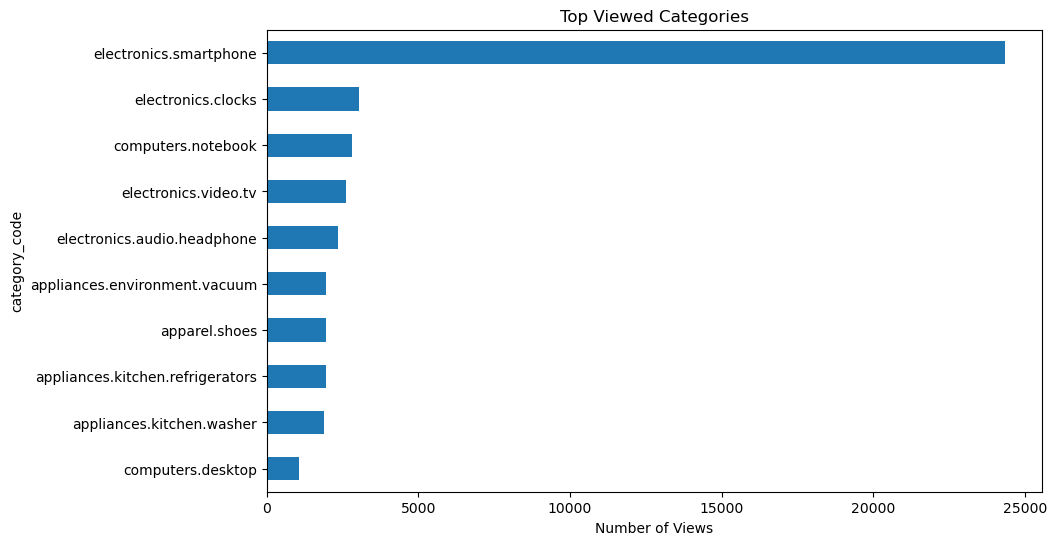

In [17]:
# Plot top viewed categories
top_viewed["view"].sort_values().plot(kind="barh", figsize=(10,6), title="Top Viewed Categories")

plt.xlabel("Number of Views")
plt.show()

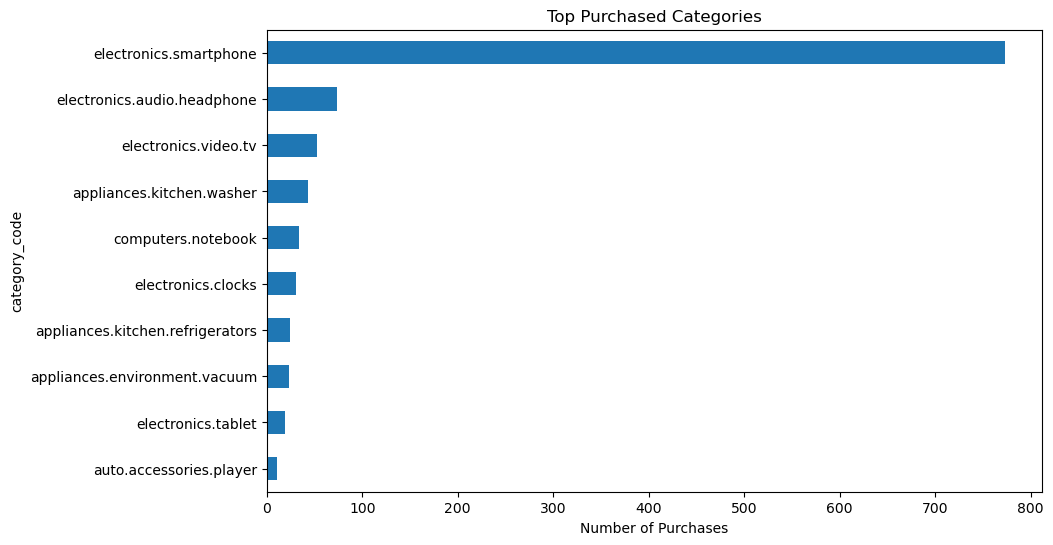

In [18]:
# Plot top purchased categories
top_purchased["purchase"].sort_values().plot(kind="barh", figsize=(10,6), title="Top Purchased Categories")

plt.xlabel("Number of Purchases")
plt.show()

### Insight

The category analysis reveals that user interest and purchasing behavior vary significantly across product categories.

Some categories attract a large number of views but have relatively low conversion rates.
This suggests that users are interested in these products but do not complete purchases.

These categories may represent opportunities for improvement, for example through:
- pricing adjustments
- better product descriptions
- improved user experience

## Price and Purchase Behavior

In this section, we analyze how product prices relate to purchasing behavior.

The goal is to explore whether higher prices are associated with lower purchase frequency and to identify potential price sensitivity among users.

In [19]:
# Filter only purchase events
purchase_data = df_clean[df_clean["event_type"] == "purchase"].copy()

purchase_data.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
69,2019-10-01 09:43:40+00:00,purchase,1004795,2053013555631882655,electronics.smartphone,xiaomi,248.89,555231925,4f50c612-2f63-4883-a1ac-b3b1846af6ce
85,2019-10-04 06:35:34+00:00,purchase,29501872,2077453854185620383,appliances.kitchen.toster,NaN,17.89,513754209,3949f397-f8ae-4205-9a21-fb78f9b8ccf2
248,2019-10-04 14:25:44+00:00,purchase,5700619,2053013553970938175,auto.accessories.player,jvc,48.88,544316753,3803467f-74b7-4027-89f7-83b75ba3fa7d
354,2019-10-01 04:58:24+00:00,purchase,1004870,2053013555631882655,electronics.smartphone,samsung,286.86,513185453,a23ae2bd-3ad9-4f8e-9f74-841eb60d7d8f
387,2019-10-02 11:42:11+00:00,purchase,2900536,2053013554776244595,appliances.kitchen.microwave,elenberg,51.46,527667838,6a30b92a-6995-4246-986b-42341683ebf9


In [20]:
# Average purchase price per category
avg_price_by_category = purchase_data.groupby("category_code")["price"].mean().sort_values(ascending=False)

avg_price_by_category.head(10)

category_code
computers.notebook                        649.334118
furniture.living_room.sofa                591.780000
electronics.smartphone                    461.535912
computers.desktop                         441.980000
electronics.camera.video                  437.080000
appliances.environment.air_conditioner    391.195000
electronics.video.tv                      339.472642
appliances.sewing_machine                 326.170000
appliances.kitchen.refrigerators          318.548750
computers.peripherals.monitor             302.860000
Name: price, dtype: float64

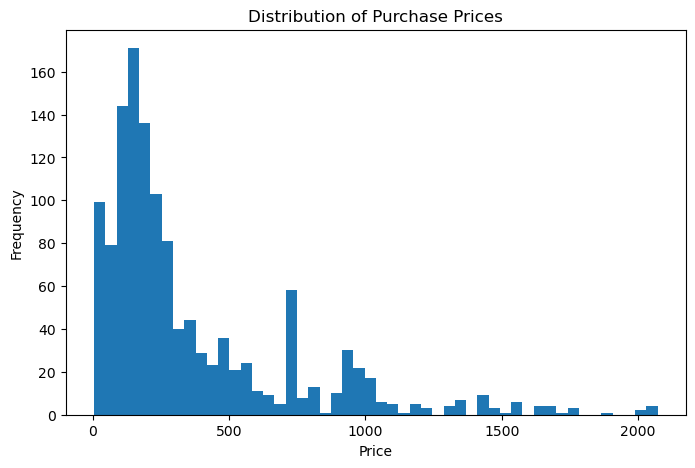

In [21]:
# Price distribution
plt.figure(figsize=(8,5))
plt.hist(purchase_data["price"], bins=50)
plt.title("Distribution of Purchase Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The distribution of purchase prices is right-skewed, indicating that most purchases occur at lower price levels.

There are relatively few high-price purchases, suggesting that users are more likely to complete purchases for cheaper products.

In [22]:
# Calculate average price per category
category_price = purchase_data.groupby("category_code")["price"].mean()

# Combine with conversion data
category_summary = category_conversion.join(category_price.rename("avg_price"), how="inner")

category_summary.head()

,cart,purchase,view,conversion_rate,avg_price
category_code,,,,,
electronics.smartphone,1249,773,24346,0.031751,461.535912
electronics.audio.headphone,134,74,2360,0.031356,122.082838
computers.components.hdd,2,4,146,0.027397,38.920000
electronics.tablet,15,19,728,0.026099,253.424211
appliances.environment.water_heater,5,8,342,0.023392,122.816250


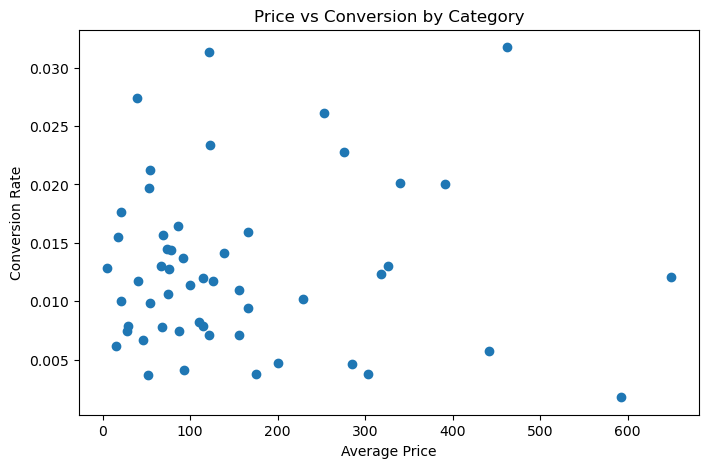

In [23]:
# Scatter plot: price vs conversion
plt.figure(figsize=(8,5))
plt.scatter(category_summary["avg_price"], category_summary["conversion_rate"])

plt.xlabel("Average Price")
plt.ylabel("Conversion Rate")
plt.title("Price vs Conversion by Category")

plt.show()

The scatter plot shows no strong linear relationship between average price and conversion rate.

This is supported by a correlation close to zero (approximately 0.03), suggesting that price alone does not explain conversion differences across categories.

This indicates that other factors, such as product type, brand, user intent, or category characteristics, may play a more important role in purchasing behavior.

### Insight

The analysis suggests that price alone is not a strong driver of conversion in this sample.

Although pricing may still influence purchasing decisions in specific categories, the overall relationship between average price and conversion rate is weak.

From a business perspective, this implies that conversion optimization should not focus only on pricing, but also on factors such as product presentation, brand trust, and user experience.

In [24]:
category_summary["avg_price"].corr(category_summary["conversion_rate"])

0.03406326443887363

## User Behavior: First Observed vs Returning Activity

In this section, we compare users' first observed activity in the dataset with their later activity.

The purpose is to understand whether users are more likely to convert after their first recorded interaction.

Note: “first observed” does not necessarily mean truly new users, since activity before October 2019 is not available in the dataset.

In [25]:
# Create a copy of the full dataset for user behavior analysis
user_df = df.copy()

# Sort data by user and time
user_df = user_df.sort_values(["user_id", "event_time"])

# Mark the first observed event for each user
user_df["is_first_event"] = user_df.groupby("user_id").cumcount() == 0

# Label event type from a user-lifecycle perspective
user_df["user_stage"] = user_df["is_first_event"].apply(
    lambda x: "first_observed" if x else "returning_activity"
)

# Inspect the result
user_df[["user_id", "event_time", "user_stage"]].head(10)

,user_id,event_time,user_stage
90424,257585460,2019-11-10 16:52:45+00:00,first_observed
43180,260013793,2019-10-01 17:47:07+00:00,first_observed
76014,289438562,2019-11-03 15:33:29+00:00,first_observed
61931,289711446,2019-11-25 17:35:02+00:00,first_observed
87234,295643776,2019-11-01 03:15:13+00:00,first_observed
94047,299840177,2019-11-14 08:12:42+00:00,first_observed
25270,306441847,2019-10-01 02:56:47+00:00,first_observed
50948,307554334,2019-11-20 20:21:27+00:00,first_observed
74251,320833938,2019-11-02 06:29:08+00:00,first_observed
85548,367167403,2019-11-05 04:30:52+00:00,first_observed


In [26]:
# Count events by user stage
user_stage_counts = user_df["user_stage"].value_counts()
print(user_stage_counts)

first_observed        88560
returning_activity    11440
Name: user_stage, dtype: int64


In [27]:
# Compare event types by user stage
conversion_by_stage = (
    user_df.groupby(["user_stage", "event_type"])
    .size()
    .unstack(fill_value=0)
)

conversion_by_stage

event_type,cart,purchase,view
user_stage,,,
first_observed,1908,1488,85164
returning_activity,208,205,11027


In [28]:
# Calculate event-level purchase rate relative to views
conversion_by_stage["conversion_rate"] = (
    conversion_by_stage["purchase"] / conversion_by_stage["view"]
)

conversion_by_stage

event_type,cart,purchase,view,conversion_rate
user_stage,,,,
first_observed,1908,1488,85164,0.017472
returning_activity,208,205,11027,0.018591


### Insight

Users with returning activity show a slightly higher conversion rate than users at their first observed event.

This suggests that familiarity with the platform, prior interest, or repeated engagement may increase the likelihood of purchase.

From a business perspective, this highlights the value of:
- retention strategies
- remarketing campaigns
- personalized recommendations

It also suggests that improving the experience for users at their first observed interaction may increase overall conversion.

Note: These groups are based on first observed activity in the dataset, not necessarily truly new versus returning customers in the real world.

## Cohort Analysis (User Retention)

In this section, users are grouped based on their first observed activity in the dataset.

The purpose of the cohort analysis is to understand whether users first observed in one month are still active in the following month.

Since the dataset covers October and November 2019, this allows a simple two-period retention analysis.

Note: Cohorts here represent users first observed in the dataset, not necessarily truly new users.

In [29]:
# Create a copy of the full dataset for cohort analysis
cohort_df = df.copy()

# Find the first observed event time for each user
first_event = cohort_df.groupby("user_id")["event_time"].min()

# Remove old first_event_time column if it already exists
cohort_df = cohort_df.drop(columns=["first_event_time"], errors="ignore")

# Merge first observed event time back into the dataframe
cohort_df = cohort_df.merge(
    first_event.rename("first_event_time"),
    on="user_id"
)

# Create cohort month and event month
cohort_df["cohort_month"] = cohort_df["first_event_time"].dt.to_period("M")
cohort_df["event_month"] = cohort_df["event_time"].dt.to_period("M")

C:\Users\vafli\AppData\Local\Temp\ipykernel_32760\3955317990.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort_df["cohort_month"] = cohort_df["first_event_time"].dt.to_period("M")
C:\Users\vafli\AppData\Local\Temp\ipykernel_32760\3955317990.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort_df["event_month"] = cohort_df["event_time"].dt.to_period("M")


In [30]:
# Check that both months are present
print(cohort_df["cohort_month"].value_counts())
print(cohort_df["event_month"].value_counts())

2019-10    51891
2019-11    48109
Freq: M, Name: cohort_month, dtype: int64
2019-10    50000
2019-11    50000
Freq: M, Name: event_month, dtype: int64


In [31]:
# Count unique users in each cohort
cohort_sizes = cohort_df.groupby("cohort_month")["user_id"].nunique()
cohort_sizes

cohort_month
2019-10    44689
2019-11    43871
Freq: M, Name: user_id, dtype: int64

In [32]:
# Build cohort table with unique active users by cohort and event month
cohort_data = (
    cohort_df.groupby(["cohort_month", "event_month"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

cohort_data

event_month,2019-10,2019-11
cohort_month,,
2019-10,44689,1544
2019-11,0,43871


In [33]:
# Calculate retention rates
cohort_retention = cohort_data.divide(cohort_sizes, axis=0)
cohort_retention

event_month,2019-10,2019-11
cohort_month,,
2019-10,1.0,0.03455
2019-11,0.0,1.00000


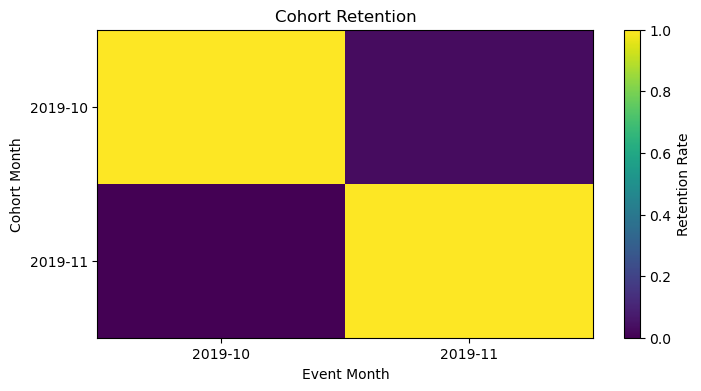

In [34]:
# Plot retention heatmap
plt.figure(figsize=(8, 4))
plt.imshow(cohort_retention, aspect="auto")
plt.colorbar(label="Retention Rate")

plt.xticks(
    range(len(cohort_retention.columns)),
    [str(col) for col in cohort_retention.columns]
)
plt.yticks(
    range(len(cohort_retention.index)),
    [str(idx) for idx in cohort_retention.index]
)

plt.title("Cohort Retention")
plt.xlabel("Event Month")
plt.ylabel("Cohort Month")
plt.show()

### Insight

The cohort analysis shows how users first observed in one month remain active in the following month.

Users first observed in October are fully active in October by definition, while only a small fraction of them remain active in November. In this sample, the October-to-November retention rate is approximately 3.5%.

This suggests that retention decreases substantially after the first observed month, highlighting an opportunity for re-engagement strategies such as personalized offers, reminders, or targeted campaigns.

It is important to note that cohorts here represent users first observed in the dataset, not necessarily truly new customers.